In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## 1. Imports and paths

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.utils.class_weight import compute_class_weight

In [3]:
ROOT = "/content/drive/My Drive/Eye Disease/Dataset"

CSV_PATH = os.path.join(ROOT, "full_df.csv")

TRAIN_DIR = os.path.join(ROOT, "ODIR-5K", "ODIR-5K" ,"Training Images")

TEST_DIR = os.path.join(ROOT, "ODIR-5K","ODIR-5K", "Testing Images")

PREPROCESS_DIR = os.path.join(ROOT, "preprocessed_images")


LOAD Patient - Level Split CSVs

In [4]:

import os
import pandas as pd

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

TRAIN_PATH = os.path.join(ROOT, "train_patient_df.csv")
VAL_PATH   = os.path.join(ROOT, "val_patient_df.csv")
TEST_PATH  = os.path.join(ROOT, "test_patient_df.csv")


# ------------------------------------------------------------
# Check that files actually exist
# ------------------------------------------------------------

print("Checking dataset files...\n")

print("Train file:", TRAIN_PATH)
print("Exists:", os.path.exists(TRAIN_PATH))

print("\nValidation file:", VAL_PATH)
print("Exists:", os.path.exists(VAL_PATH))

print("\nTest file:", TEST_PATH)
print("Exists:", os.path.exists(TEST_PATH))


# ------------------------------------------------------------
# Stop immediately if any file is missing
# ------------------------------------------------------------

assert os.path.exists(TRAIN_PATH), " Training CSV not found!"
assert os.path.exists(VAL_PATH), " Validation CSV not found!"
assert os.path.exists(TEST_PATH), " Test CSV not found!"


# ------------------------------------------------------------
# Load CSVs
# ------------------------------------------------------------

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)


# ------------------------------------------------------------
# Display basic information
# ------------------------------------------------------------

print("PATIENT-LEVEL DATA LOADED SUCCESSFULLY")

print("\nTrain shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Checking dataset files...

Train file: /content/drive/My Drive/Eye Disease/Dataset/train_patient_df.csv
Exists: True

Validation file: /content/drive/My Drive/Eye Disease/Dataset/val_patient_df.csv
Exists: True

Test file: /content/drive/My Drive/Eye Disease/Dataset/test_patient_df.csv
Exists: True
PATIENT-LEVEL DATA LOADED SUCCESSFULLY

Train shape: (2350, 11)
Validation shape: (504, 11)
Test shape: (504, 11)


In [5]:
print(train_df.head())

   patient_id right_filename left_filename  N  D  G  C  A  H  M  O
0           1    1_right.jpg    1_left.jpg  1  0  0  0  0  0  0  0
1           2    2_right.jpg           NaN  0  1  0  0  0  0  0  1
2           3            NaN    3_left.jpg  0  0  0  0  0  0  0  1
3           4    4_right.jpg    4_left.jpg  0  1  0  0  0  0  0  1
4           5    5_right.jpg    5_left.jpg  0  1  0  0  0  0  0  0



 VERIFY DATA STRUCTURE


In [6]:
label_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

expected_columns = [
    'patient_id',
    'right_filename',
    'left_filename'
] + label_cols


print("Expected columns:")
print(expected_columns)

print("\nActual columns:")
print(train_df.columns.tolist())


# ------------------------------------------------------------
# Verify all required columns exist
# ------------------------------------------------------------

for column in expected_columns:
    assert column in train_df.columns, \
        f" Missing column in train_df: {column}"

    assert column in val_df.columns, \
        f" Missing column in val_df: {column}"

    assert column in test_df.columns, \
        f" Missing column in test_df: {column}"


print("\n All required columns are present.")

Expected columns:
['patient_id', 'right_filename', 'left_filename', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

Actual columns:
['patient_id', 'right_filename', 'left_filename', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

 All required columns are present.


 INSPECT DATA


In [7]:
print("TRAIN")
display(train_df.head())

print("\nVALIDATION")
display(val_df.head())

print("\nTEST")
display(test_df.head())

TRAIN


,patient_id,right_filename,left_filename,N,D,G,C,A,H,M,O
0,1,1_right.jpg,1_left.jpg,1,0,0,0,0,0,0,0
1,2,2_right.jpg,NaN,0,1,0,0,0,0,0,1
2,3,NaN,3_left.jpg,0,0,0,0,0,0,0,1
3,4,4_right.jpg,4_left.jpg,0,1,0,0,0,0,0,1
4,5,5_right.jpg,5_left.jpg,0,1,0,0,0,0,0,0



VALIDATION


,patient_id,right_filename,left_filename,N,D,G,C,A,H,M,O
0,7,7_right.jpg,7_left.jpg,0,1,0,0,0,0,0,1
1,13,13_right.jpg,13_left.jpg,0,0,0,0,0,0,1,0
2,18,18_right.jpg,18_left.jpg,0,0,0,0,0,0,1,0
3,24,24_right.jpg,24_left.jpg,0,0,0,1,0,0,0,0
4,27,27_right.jpg,27_left.jpg,0,1,0,0,0,0,0,1



TEST


,patient_id,right_filename,left_filename,N,D,G,C,A,H,M,O
0,0,0_right.jpg,0_left.jpg,0,0,0,1,0,0,0,0
1,15,15_right.jpg,15_left.jpg,0,0,0,0,0,0,0,1
2,33,33_right.jpg,33_left.jpg,0,0,0,0,0,0,0,1
3,47,47_right.jpg,47_left.jpg,0,1,0,0,0,0,0,1
4,49,49_right.jpg,49_left.jpg,0,1,0,0,0,0,0,0



TRAINING SET — MULTI-LABEL DISEASE DISTRIBUTION


In [8]:
train_positive_counts = train_df[label_cols].sum()

train_negative_counts = len(train_df) - train_positive_counts

train_prevalence = train_positive_counts / len(train_df)

distribution_df = pd.DataFrame({
    'Positive': train_positive_counts,
    'Negative': train_negative_counts,
    'Prevalence': train_prevalence
})

distribution_df['Prevalence (%)'] = (
    distribution_df['Prevalence'] * 100
)

display(distribution_df)

,Positive,Negative,Prevalence,Prevalence (%)
N,772,1578,0.328511,32.851064
D,772,1578,0.328511,32.851064
G,138,2212,0.058723,5.872340
C,147,2203,0.062553,6.255319
A,110,2240,0.046809,4.680851
H,70,2280,0.029787,2.978723
M,127,2223,0.054043,5.404255
O,615,1735,0.261702,26.170213



 SORT DISEASES FROM RAREST → MOST COMMON


In [9]:
distribution_sorted = distribution_df.sort_values(
    by='Positive'
)

display(distribution_sorted)

,Positive,Negative,Prevalence,Prevalence (%)
H,70,2280,0.029787,2.978723
A,110,2240,0.046809,4.680851
M,127,2223,0.054043,5.404255
G,138,2212,0.058723,5.872340
C,147,2203,0.062553,6.255319
O,615,1735,0.261702,26.170213
N,772,1578,0.328511,32.851064
D,772,1578,0.328511,32.851064



 IMBALANCE RATIO


In [10]:
max_positive = train_positive_counts.max()

distribution_df['Imbalance Ratio'] = (
    max_positive / train_positive_counts
)

display(
    distribution_df.sort_values(
        by='Imbalance Ratio',
        ascending=False
    )
)

,Positive,Negative,Prevalence,Prevalence (%),Imbalance Ratio
H,70,2280,0.029787,2.978723,11.028571
A,110,2240,0.046809,4.680851,7.018182
M,127,2223,0.054043,5.404255,6.078740
G,138,2212,0.058723,5.872340,5.594203
C,147,2203,0.062553,6.255319,5.251701
O,615,1735,0.261702,26.170213,1.255285
N,772,1578,0.328511,32.851064,1.000000
D,772,1578,0.328511,32.851064,1.000000


 TRAINING SET DISEASE DISTRIBUTION

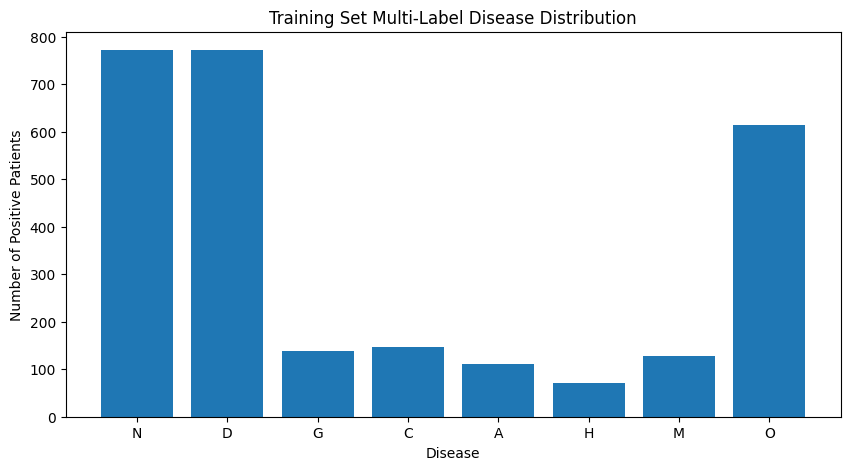

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    train_positive_counts.index,
    train_positive_counts.values
)

plt.xlabel("Disease")
plt.ylabel("Number of Positive Patients")
plt.title("Training Set Multi-Label Disease Distribution")

plt.show()


 MULTI-LABEL DISEASE CO-OCCURRENCE


In [12]:
# Matrix multiplication gives the number of patients
# where each pair of diseases occurs together.

cooccurrence_matrix = train_df[label_cols].T.dot(
    train_df[label_cols]
)

display(cooccurrence_matrix)

,N,D,G,C,A,H,M,O
N,772,0,0,0,0,0,0,0
D,0,772,17,29,11,35,13,189
G,0,17,138,2,8,5,4,28
C,0,29,2,147,0,2,0,22
A,0,11,8,0,110,2,3,9
H,0,35,5,2,2,70,0,6
M,0,13,4,0,3,0,127,33
O,0,189,28,22,9,6,33,615



 CO-OCCURRENCE HEATMAP



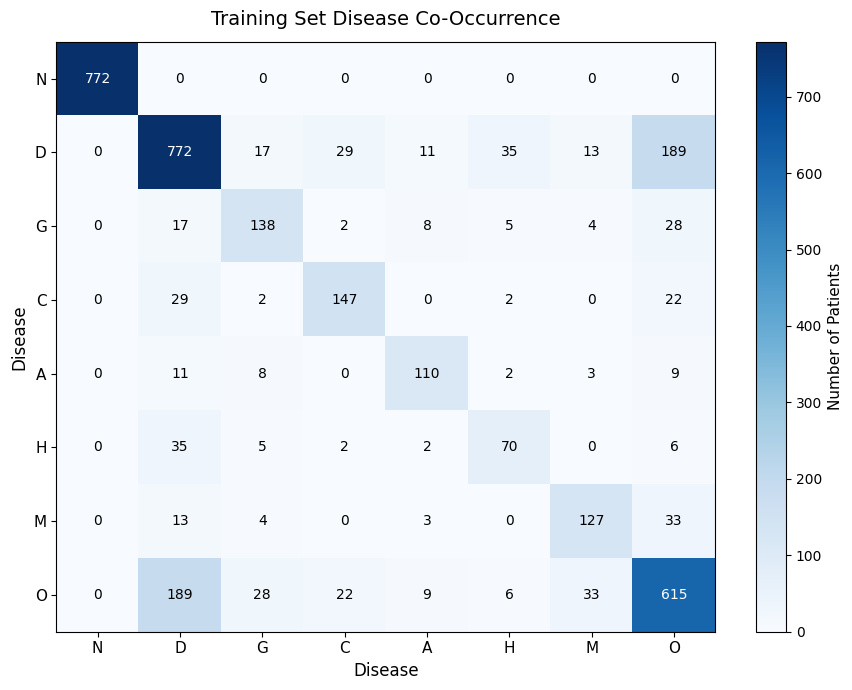

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.imshow(
    cooccurrence_matrix.values,
    cmap="Blues",          # Changed to a cleaner blue palette
    aspect="auto"
)

# Axis labels
plt.xticks(
    range(len(label_cols)),
    label_cols,
    fontsize=11
)

plt.yticks(
    range(len(label_cols)),
    label_cols,
    fontsize=11
)

plt.xlabel("Disease", fontsize=12)
plt.ylabel("Disease", fontsize=12)

plt.title(
    "Training Set Disease Co-Occurrence",
    fontsize=14,
    pad=12
)

# Color bar
cbar = plt.colorbar()
cbar.set_label(
    "Number of Patients",
    fontsize=11
)

# Add numerical values
for i in range(len(label_cols)):
    for j in range(len(label_cols)):

        value = cooccurrence_matrix.iloc[i, j]

        # Use white text for darker cells
        # and black text for lighter cells
        if value > cooccurrence_matrix.values.max() * 0.45:
            text_color = "white"
        else:
            text_color = "black"

        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=10
        )

plt.tight_layout()
plt.show()

## STAGE 1 — SINGLE-EYE DATA PREPARATION + BALANCING


In [14]:

# FINAL BALANCING STRATEGY:
#
#   1. Start ONLY from train_df
#   2. Convert training patients into eye-level records
#   3. Keep patient_id for traceability
#   4. Use PREPROCESSED images only
#   5. Calculate moderated disease weights:
#
#          sqrt(max_positive_count / disease_count)
#
#   6. Calculate multi-label sample weight using the
#      AVERAGE of the weights of diseases present
#
#   7. Cap sample weights at 3.0
#
#   8. Use WeightedRandomSampler
#
# IMPORTANT:
#   - train_df itself is NOT modified
#   - val_df is NOT balanced
#   - test_df is NOT balanced
#   - No images are duplicated physically
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

from torch.utils.data import WeightedRandomSampler


# ============================================================
# 2. EXISTING VARIABLES
# ============================================================
#
# We assume these were already created in the previous
# notebooks/cells:
#
#   train_df
#   val_df
#   test_df
#   label_cols
#
# We DO NOT redefine label_cols.
# ============================================================

print("Training patients:", len(train_df))
print("Validation patients:", len(val_df))
print("Test patients:", len(test_df))

print("\nDisease labels:")
print(label_cols)


# ============================================================
# 3. VERIFY THE ACTUAL train_df COLUMN NAMES
# ============================================================

required_columns = [
    'patient_id',
    'right_filename',
    'left_filename'
] + label_cols

missing_columns = [
    col for col in required_columns
    if col not in train_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns in train_df: {missing_columns}"
    )

print("\nRequired train_df columns verified.")
print(train_df.columns.tolist())


# ============================================================
# 4. DEFINE THE PREPROCESSED IMAGE DIRECTORY
# ============================================================
#
# Your preprocessed images are stored here.
#
# We use the FILENAMES from train_df and construct the
# corresponding paths inside the PREPROCESSED folder.
#
# This ensures Stage 1 uses the same preprocessed images
# that we verified earlier.
# ============================================================

PREPROCESSED_DIR = (
    "/content/drive/My Drive/"
    "Eye Disease/Dataset/preprocessed_images"
)


# ============================================================
# 5. HELPER FUNCTION TO BUILD PREPROCESSED IMAGE PATH
# ============================================================

def get_preprocessed_path(filename):
    """
    Convert a filename such as:

        1_right.jpg

    into:

        /content/.../preprocessed_images/1_right.jpg
    """

    if pd.isna(filename):
        return None

    return os.path.join(
        PREPROCESSED_DIR,
        str(filename)
    )


# ============================================================
# 6. CREATE STAGE-1 EYE-LEVEL TRAINING RECORDS
# ============================================================
#
# One row = one available eye.
#
# Bilateral patient:
#
#       patient 1
#       ├── right
#       └── left
#
# becomes TWO rows.
#
# Right-only patient:
#
#       patient 2
#       └── right
#
# becomes ONE row.
#
# Left-only patient:
#
#       patient 3
#       └── left
#
# becomes ONE row.
#
# patient_id is retained.
# ============================================================

stage1_records = []


for _, row in train_df.iterrows():

    # --------------------------------------------------------
    # RIGHT EYE
    # --------------------------------------------------------

    if pd.notna(row['right_filename']):

        record = {
            'patient_id': row['patient_id'],
            'eye': 'right',
            'filename': row['right_filename'],
            'image_path': get_preprocessed_path(
                row['right_filename']
            )
        }

        # Copy disease labels
        for label in label_cols:
            record[label] = row[label]

        stage1_records.append(record)


    # --------------------------------------------------------
    # LEFT EYE
    # --------------------------------------------------------

    if pd.notna(row['left_filename']):

        record = {
            'patient_id': row['patient_id'],
            'eye': 'left',
            'filename': row['left_filename'],
            'image_path': get_preprocessed_path(
                row['left_filename']
            )
        }

        # Copy disease labels
        for label in label_cols:
            record[label] = row[label]

        stage1_records.append(record)


# Convert list of records into dataframe

stage1_train_df = pd.DataFrame(stage1_records)


# ============================================================
# 7. CHECK STAGE-1 SIZE
# ============================================================

print("\n" + "=" * 60)
print("STAGE-1 EYE-LEVEL DATASET")
print("=" * 60)

print(
    "Number of eye samples:",
    len(stage1_train_df)
)

print(
    "Unique patients:",
    stage1_train_df['patient_id'].nunique()
)

print(
    "Right-eye samples:",
    (
        stage1_train_df['eye'] == 'right'
    ).sum()
)

print(
    "Left-eye samples:",
    (
        stage1_train_df['eye'] == 'left'
    ).sum()
)


# ============================================================
# EXPECTED RESULT
# ============================================================
#
# From your current training split:
#
# Both eyes  = 2141
# Right only = 109
# Left only  = 100
#
# Therefore:
#
# Right = 2141 + 109 = 2250
# Left  = 2141 + 100 = 2241
#
# Total = 4491 eyes
# ============================================================

expected_right = 2141 + 109
expected_left = 2141 + 100
expected_total = expected_right + expected_left

if (
    len(stage1_train_df) != expected_total
    or
    (stage1_train_df['eye'] == 'right').sum()
    != expected_right
    or
    (stage1_train_df['eye'] == 'left').sum()
    != expected_left
):

    raise ValueError(
        "Stage-1 eye counts do not match the "
        "expected training split."
    )

print("\nEye-count verification PASSED.")


# ============================================================
# 8. VERIFY PREPROCESSED IMAGE PATHS
# ============================================================
#
# We now verify that every Stage-1 image actually exists.
#
# This is important because train_df stores FILENAMES,
# whereas the model needs actual preprocessed-image paths.
# ============================================================

stage1_train_df['image_exists'] = (
    stage1_train_df['image_path']
    .apply(os.path.isfile)
)


missing_image_count = (
    ~stage1_train_df['image_exists']
).sum()

print(
    "\nMissing preprocessed images:",
    missing_image_count
)


if missing_image_count != 0:

    missing_files = stage1_train_df.loc[
        ~stage1_train_df['image_exists'],
        'image_path'
    ].head(20).tolist()

    print("\nExample missing paths:")
    for path in missing_files:
        print(path)

    raise FileNotFoundError(
        "Some preprocessed images could not be found."
    )


# We no longer need this temporary verification column.

stage1_train_df.drop(
    columns=['image_exists'],
    inplace=True
)

print("Preprocessed-image verification PASSED.")


# ============================================================
# 9. VERIFY DISEASE LABELS
# ============================================================

missing_labels = (
    stage1_train_df[label_cols]
    .isna()
    .sum()
)

print("\nMissing disease labels:")
print(missing_labels)


if missing_labels.sum() != 0:

    raise ValueError(
        "Missing disease labels found in Stage-1 data."
    )

print("Disease-label verification PASSED.")


# ============================================================
# 10. VERIFY EVERY SAMPLE HAS AT LEAST ONE LABEL
# ============================================================
#
# Because this is a multi-label problem, a sample can have:
#
#       one positive disease
#
# or
#
#       multiple positive diseases.
#
# But we should not have an unlabeled sample.
# ============================================================

positive_label_count = (
    stage1_train_df[label_cols]
    .sum(axis=1)
)

zero_label_samples = (
    positive_label_count == 0
).sum()

print(
    "\nSamples with zero positive labels:",
    zero_label_samples
)


if zero_label_samples != 0:

    raise ValueError(
        "Found Stage-1 samples with no positive disease label."
    )

print("Label-integrity verification PASSED.")


# ============================================================
# 11. STAGE-1 ORIGINAL DISEASE DISTRIBUTION
# ============================================================

stage1_positive_counts = (
    stage1_train_df[label_cols]
    .sum()
)

stage1_distribution = pd.DataFrame({

    'Positive': stage1_positive_counts,

    'Negative':
        len(stage1_train_df)
        - stage1_positive_counts,

    'Prevalence (%)':
        (
            stage1_positive_counts
            / len(stage1_train_df)
        ) * 100
})


print("\n" + "=" * 60)
print("STAGE-1 ORIGINAL DISEASE DISTRIBUTION")
print("=" * 60)

display(stage1_distribution)


# ============================================================
# 12. CALCULATE MODERATED DISEASE WEIGHTS
# ============================================================
#
# FINAL FORMULA:
#
#       disease_weight =
#       sqrt(max_positive_count / positive_count)
#
# This moderates the effect of class imbalance.
# ============================================================

max_positive_count = (
    stage1_positive_counts.max()
)


disease_weights = np.sqrt(
    max_positive_count
    / stage1_positive_counts
)


disease_weight_df = pd.DataFrame({

    'Positive Count':
        stage1_positive_counts,

    'Disease Weight':
        disease_weights
})


print("\n" + "=" * 60)
print("MODERATED DISEASE WEIGHTS")
print("=" * 60)

display(disease_weight_df)


# ============================================================
# 13. MULTI-LABEL SAMPLE WEIGHT
# ============================================================
#
# We DO NOT SUM the weights.
#
# Instead:
#
#       sample weight =
#       MEAN(weight of diseases present)
#
# Example:
#
#       H only
#       = weight(H)
#
#       H + D
#       = (weight(H) + weight(D)) / 2
#
#       D + O
#       = (weight(D) + weight(O)) / 2
#
# This prevents multi-disease samples from receiving
# excessively large sampling weights.
# ============================================================

def calculate_sample_weight(row):

    present_labels = [
        label
        for label in label_cols
        if row[label] == 1
    ]

    # Safety fallback
    if len(present_labels) == 0:
        return 1.0

    weights = [
        disease_weights[label]
        for label in present_labels
    ]

    return np.mean(weights)


stage1_train_df['sample_weight'] = (
    stage1_train_df
    .apply(
        calculate_sample_weight,
        axis=1
    )
)


# ============================================================
# 14. CAP EXTREME SAMPLE WEIGHTS
# ============================================================
#
# Final agreed cap:
#
#       MAX_SAMPLE_WEIGHT = 3.0
#
# This prevents rare combinations from dominating the
# sampling process.
# ============================================================

MAX_SAMPLE_WEIGHT = 3.0

stage1_train_df['sample_weight'] = (
    stage1_train_df['sample_weight']
    .clip(
        upper=MAX_SAMPLE_WEIGHT
    )
)


# ============================================================
# 15. SAMPLE-WEIGHT SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("STAGE-1 SAMPLE WEIGHTS")
print("=" * 60)

print(
    stage1_train_df['sample_weight']
    .describe()
)


# ============================================================
# 16. CREATE WEIGHTED RANDOM SAMPLER
# ============================================================
#
# IMPORTANT:
#
# WeightedRandomSampler does NOT physically duplicate images.
#
# It changes the probability of selecting each training sample.
#
# replacement=True means a rare sample can be selected more
# than once during an epoch.
# ============================================================

sample_weights = torch.tensor(
    stage1_train_df['sample_weight'].values,
    dtype=torch.double
)


stage1_sampler = WeightedRandomSampler(

    weights=sample_weights,

    num_samples=len(stage1_train_df),

    replacement=True
)


print("\n" + "=" * 60)
print("STAGE-1 SAMPLER CREATED")
print("=" * 60)

print(
    "Samples per epoch:",
    len(stage1_train_df)
)

print(
    "Replacement:",
    stage1_sampler.replacement
)


# ============================================================
# 17. PATIENT-LEAKAGE CHECK
# ============================================================
#
# Stage 1 was created ONLY from train_df.
#
# Therefore every patient must belong to the training split.
#
# We explicitly verify this.
# ============================================================

train_patient_ids = set(
    train_df['patient_id']
)

stage1_patient_ids = set(
    stage1_train_df['patient_id']
)

unexpected_patients = (
    stage1_patient_ids
    - train_patient_ids
)


print(
    "\nPatients outside training split:",
    len(unexpected_patients)
)


if len(unexpected_patients) != 0:

    raise ValueError(
        "PATIENT LEAKAGE DETECTED!"
    )

print(
    "Patient-level split integrity PASSED."
)


# ============================================================
# 18. FINAL STAGE-1 DATAFRAME PREVIEW
# ============================================================

print("\n" + "=" * 60)
print("FINAL STAGE-1 TRAINING VIEW")
print("=" * 60)

display(
    stage1_train_df[
        [
            'patient_id',
            'eye',
            'filename',
            'image_path'
        ] + label_cols + [
            'sample_weight'
        ]
    ].head(10)
)


# ============================================================
# 19. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("✅ STAGE-1 BALANCING PREPARATION COMPLETE")
print("=" * 60)

print(
    "Training patients:",
    len(train_df)
)

print(
    "Stage-1 eye samples:",
    len(stage1_train_df)
)

print(
    "Right-eye samples:",
    (
        stage1_train_df['eye'] == 'right'
    ).sum()
)

print(
    "Left-eye samples:",
    (
        stage1_train_df['eye'] == 'left'
    ).sum()
)

print(
    "Maximum sample weight:",
    stage1_train_df['sample_weight'].max()
)

print(
    "Minimum sample weight:",
    stage1_train_df['sample_weight'].min()
)

print(
    "Patient leakage:",
    len(unexpected_patients)
)

print("\nAll Stage-1 checks completed successfully.")

Training patients: 2350
Validation patients: 504
Test patients: 504

Disease labels:
['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

Required train_df columns verified.
['patient_id', 'right_filename', 'left_filename', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

STAGE-1 EYE-LEVEL DATASET
Number of eye samples: 4491
Unique patients: 2350
Right-eye samples: 2250
Left-eye samples: 2241

Eye-count verification PASSED.

Missing preprocessed images: 0
Preprocessed-image verification PASSED.

Missing disease labels:
N    0
D    0
G    0
C    0
A    0
H    0
M    0
O    0
dtype: int64
Disease-label verification PASSED.

Samples with zero positive labels: 0
Label-integrity verification PASSED.

STAGE-1 ORIGINAL DISEASE DISTRIBUTION


,Positive,Negative,Prevalence (%)
N,1502,2989,33.444667
D,1491,3000,33.199733
G,269,4222,5.989757
C,286,4205,6.368292
A,215,4276,4.787352
H,140,4351,3.117346
M,226,4265,5.032287
O,1089,3402,24.248497



MODERATED DISEASE WEIGHTS


,Positive Count,Disease Weight
N,1502,1.000000
D,1491,1.003682
G,269,2.362973
C,286,2.291669
A,215,2.643113
H,140,3.275450
M,226,2.577987
O,1089,1.174413



STAGE-1 SAMPLE WEIGHTS
count    4491.000000
mean        1.344148
std         0.568318
min         1.000000
25%         1.000000
50%         1.003682
75%         1.174413
max         3.000000
Name: sample_weight, dtype: float64

STAGE-1 SAMPLER CREATED
Samples per epoch: 4491
Replacement: True

Patients outside training split: 0
Patient-level split integrity PASSED.

FINAL STAGE-1 TRAINING VIEW


,patient_id,eye,filename,image_path,N,D,G,C,A,H,M,O,sample_weight
0,1,right,1_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,1,0,0,0,0,0,0,0,1.000000
1,1,left,1_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,1,0,0,0,0,0,0,0,1.000000
2,2,right,2_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.089048
3,3,left,3_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,0,0,0,0,0,0,1,1.174413
4,4,right,4_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.089048
5,4,left,4_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.089048
6,5,right,5_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,0,1.003682
7,5,left,5_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,0,1.003682
8,6,right,6_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.089048
9,6,left,6_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.089048



✅ STAGE-1 BALANCING PREPARATION COMPLETE
Training patients: 2350
Stage-1 eye samples: 4491
Right-eye samples: 2250
Left-eye samples: 2241
Maximum sample weight: 3.0
Minimum sample weight: 1.0
Patient leakage: 0

All Stage-1 checks completed successfully.



 STAGE 1 — VERIFY THE EFFECT OF THE WEIGHTED SAMPLER


In [15]:


# We will simulate one epoch of sampling and check whether
# minority diseases receive more representation.
#
# IMPORTANT:
# This does NOT train the model.
# It only validates our balancing strategy.
# ============================================================

# ------------------------------------------------------------
# 1. DRAW ONE EPOCH FROM THE SAMPLER
# ------------------------------------------------------------

sampled_indices = list(iter(stage1_sampler))

print("Number of sampled indices:", len(sampled_indices))


# ------------------------------------------------------------
# 2. CREATE THE SAMPLED TRAINING VIEW
# ------------------------------------------------------------

sampled_stage1_df = stage1_train_df.iloc[
    sampled_indices
].reset_index(drop=True)


# ------------------------------------------------------------
# 3. CALCULATE DISEASE DISTRIBUTION AFTER SAMPLING
# ------------------------------------------------------------

sampled_positive_counts = (
    sampled_stage1_df[label_cols]
    .sum()
)

sampled_distribution = pd.DataFrame({

    'Original Positive':
        stage1_positive_counts,

    'Sampled Positive':
        sampled_positive_counts,

    'Original Prevalence (%)':
        (
            stage1_positive_counts /
            len(stage1_train_df)
        ) * 100,

    'Sampled Prevalence (%)':
        (
            sampled_positive_counts /
            len(sampled_stage1_df)
        ) * 100
})


# ------------------------------------------------------------
# 4. SHOW BEFORE VS AFTER
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE-1 BALANCING EFFECT")
print("=" * 70)

display(sampled_distribution)


# ------------------------------------------------------------
# 5. CALCULATE CHANGE IN PREVALENCE
# ------------------------------------------------------------

sampled_distribution['Change (%)'] = (
    sampled_distribution['Sampled Prevalence (%)']
    -
    sampled_distribution['Original Prevalence (%)']
)


print("\n" + "=" * 70)
print("CHANGE IN DISEASE PREVALENCE")
print("=" * 70)

display(
    sampled_distribution[
        [
            'Original Prevalence (%)',
            'Sampled Prevalence (%)',
            'Change (%)'
        ]
    ]
)


# ------------------------------------------------------------
# 6. VERIFY THAT RARE DISEASES ARE RECEIVING MORE
#    SAMPLING ATTENTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BALANCING CHECK")
print("=" * 70)

for label in label_cols:

    original = sampled_distribution.loc[
        label,
        'Original Prevalence (%)'
    ]

    sampled = sampled_distribution.loc[
        label,
        'Sampled Prevalence (%)'
    ]

    print(
        f"{label}: "
        f"{original:.2f}% → "
        f"{sampled:.2f}%"
    )


# ------------------------------------------------------------
# 7. CHECK THE IMPORTANT RARE CLASSES
# ------------------------------------------------------------

rare_classes = ['G', 'C', 'A', 'H', 'M']

print("\nRare-disease sampling check:")

for label in rare_classes:

    original = sampled_distribution.loc[
        label,
        'Original Prevalence (%)'
    ]

    sampled = sampled_distribution.loc[
        label,
        'Sampled Prevalence (%)'
    ]

    print(
        f"{label}: "
        f"{original:.2f}% → "
        f"{sampled:.2f}%"
    )


# ------------------------------------------------------------
# 8. FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ SAMPLER EFFECT CHECK COMPLETE")
print("=" * 70)

print(
    "The sampled distribution should show increased "
    "representation of the minority diseases."
)

print(
    "This confirms that the WeightedRandomSampler is "
    "actually applying the intended balancing strategy."
)

Number of sampled indices: 4491

STAGE-1 BALANCING EFFECT


,Original Positive,Sampled Positive,Original Prevalence (%),Sampled Prevalence (%)
N,1502,1071,33.444667,23.847695
D,1491,1257,33.199733,27.989312
G,269,462,5.989757,10.287241
C,286,441,6.368292,9.819639
A,215,424,4.787352,9.441104
H,140,287,3.117346,6.390559
M,226,412,5.032287,9.173903
O,1089,1033,24.248497,23.001559



CHANGE IN DISEASE PREVALENCE


,Original Prevalence (%),Sampled Prevalence (%),Change (%)
N,33.444667,23.847695,-9.596972
D,33.199733,27.989312,-5.210421
G,5.989757,10.287241,4.297484
C,6.368292,9.819639,3.451347
A,4.787352,9.441104,4.653752
H,3.117346,6.390559,3.273213
M,5.032287,9.173903,4.141617
O,24.248497,23.001559,-1.246938



BALANCING CHECK
N: 33.44% → 23.85%
D: 33.20% → 27.99%
G: 5.99% → 10.29%
C: 6.37% → 9.82%
A: 4.79% → 9.44%
H: 3.12% → 6.39%
M: 5.03% → 9.17%
O: 24.25% → 23.00%

Rare-disease sampling check:
G: 5.99% → 10.29%
C: 6.37% → 9.82%
A: 4.79% → 9.44%
H: 3.12% → 6.39%
M: 5.03% → 9.17%

✅ SAMPLER EFFECT CHECK COMPLETE
The sampled distribution should show increased representation of the minority diseases.
This confirms that the WeightedRandomSampler is actually applying the intended balancing strategy.


In [16]:
# ============================================================
# STAGE 2 — BILATERAL PATIENT-LEVEL DATA + BALANCING
# ============================================================
#
# FINAL STAGE-2 STRATEGY
#
# Stage 2 is the bilateral learning stage.
#
# ONLY patients having BOTH:
#       - right eye
#       - left eye
#
# are used.
#
# We work directly from train_df because train_df is already
# the correct patient-level dataframe.
#
#
# STAGE 1:
#
#     train_df
#        ↓
#     eye-level
#        ↓
#     4491 eyes
#        ↓
#     eye-level WeightedRandomSampler
#
#
# STAGE 2:
#
#     train_df
#        ↓
#     bilateral patients only
#        ↓
#     patient-level WeightedRandomSampler
#
#
# IMPORTANT:
# - No balancing of validation data
# - No balancing of test data
# - No physical duplication of images
# - No patient can appear in multiple splits
# - Preprocessed images ONLY
# ============================================================


# ============================================================
# 1. BASIC INFORMATION
# ============================================================

print("=" * 70)
print("STAGE 2 — BILATERAL PATIENT-LEVEL DATA")
print("=" * 70)

print("Training patients:", len(train_df))
print("Validation patients:", len(val_df))
print("Test patients:", len(test_df))

print("\nDisease labels:")
print(label_cols)


# ============================================================
# 2. VERIFY train_df COLUMNS
# ============================================================

required_columns = [
    'patient_id',
    'right_filename',
    'left_filename'
] + label_cols


missing_columns = [
    col
    for col in required_columns
    if col not in train_df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing columns in train_df: {missing_columns}"
    )


print("\nRequired train_df columns verified.")


# ============================================================
# 3. IDENTIFY BILATERAL TRAINING PATIENTS
# ============================================================
#
# A bilateral patient MUST have:
#
#       right_filename != NaN
#       left_filename  != NaN
#
# We deliberately do NOT include:
#
#       right-only patients
#       left-only patients
#
# in Stage 2.
# ============================================================

has_right = train_df['right_filename'].notna()
has_left = train_df['left_filename'].notna()

bilateral_mask = has_right & has_left

stage2_train_df = (
    train_df.loc[bilateral_mask]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 4. CHECK BILATERAL PATIENT COUNT
# ============================================================

print("\n" + "=" * 70)
print("BILATERAL TRAINING PATIENTS")
print("=" * 70)

print(
    "Total training patients:",
    len(train_df)
)

print(
    "Bilateral patients:",
    len(stage2_train_df)
)

print(
    "Right-only excluded:",
    (has_right & ~has_left).sum()
)

print(
    "Left-only excluded:",
    (~has_right & has_left).sum()
)


# Your previously verified training split was:
#
#       Both eyes  = 2141
#       Right only = 109
#       Left only  = 100
#
# Therefore Stage 2 should contain exactly 2141 patients.

EXPECTED_BILATERAL = 2141


if len(stage2_train_df) != EXPECTED_BILATERAL:

    raise ValueError(
        f"Expected {EXPECTED_BILATERAL} bilateral patients, "
        f"but found {len(stage2_train_df)}."
    )


print("\nBilateral-patient count verification PASSED.")


# ============================================================
# 5. VERIFY EVERY STAGE-2 PATIENT HAS BOTH FILENAMES
# ============================================================

missing_right = (
    stage2_train_df['right_filename']
    .isna()
    .sum()
)

missing_left = (
    stage2_train_df['left_filename']
    .isna()
    .sum()
)


print("\nMissing right filenames:", missing_right)
print("Missing left filenames:", missing_left)


if missing_right != 0 or missing_left != 0:

    raise ValueError(
        "Stage-2 contains a patient without both eye filenames."
    )


print("Bilateral filename verification PASSED.")


# ============================================================
# 6. BUILD PREPROCESSED IMAGE PATHS
# ============================================================
#
# train_df contains FILENAMES.
#
# Stage 2 needs the corresponding PREPROCESSED image paths.
#
# We are NOT going back to the original/raw dataset.
# ============================================================

stage2_train_df['right_image_path'] = (
    stage2_train_df['right_filename']
    .apply(get_preprocessed_path)
)

stage2_train_df['left_image_path'] = (
    stage2_train_df['left_filename']
    .apply(get_preprocessed_path)
)


# ============================================================
# 7. VERIFY PREPROCESSED RIGHT-EYE FILES
# ============================================================

right_exists = (
    stage2_train_df['right_image_path']
    .apply(os.path.isfile)
)

missing_right_files = (
    ~right_exists
).sum()


print("\nMissing right preprocessed files:",
      missing_right_files)


if missing_right_files != 0:

    print("\nExample missing right files:")

    display(
        stage2_train_df.loc[
            ~right_exists,
            [
                'patient_id',
                'right_filename',
                'right_image_path'
            ]
        ].head(20)
    )

    raise FileNotFoundError(
        "Some right-eye preprocessed images are missing."
    )


# ============================================================
# 8. VERIFY PREPROCESSED LEFT-EYE FILES
# ============================================================

left_exists = (
    stage2_train_df['left_image_path']
    .apply(os.path.isfile)
)

missing_left_files = (
    ~left_exists
).sum()


print(
    "Missing left preprocessed files:",
    missing_left_files
)


if missing_left_files != 0:

    print("\nExample missing left files:")

    display(
        stage2_train_df.loc[
            ~left_exists,
            [
                'patient_id',
                'left_filename',
                'left_image_path'
            ]
        ].head(20)
    )

    raise FileNotFoundError(
        "Some left-eye preprocessed images are missing."
    )


print("\nPreprocessed-image verification PASSED.")


# ============================================================
# 9. VERIFY DISEASE LABELS
# ============================================================

missing_labels = (
    stage2_train_df[label_cols]
    .isna()
    .sum()
)


print("\nMissing disease labels:")
print(missing_labels)


if missing_labels.sum() != 0:

    raise ValueError(
        "Missing disease labels found in Stage 2."
    )


print("\nDisease-label verification PASSED.")


# ============================================================
# 10. VERIFY NO PATIENT HAS ZERO DISEASE LABELS
# ============================================================

positive_label_count = (
    stage2_train_df[label_cols]
    .sum(axis=1)
)


zero_label_patients = (
    positive_label_count == 0
).sum()


print(
    "\nPatients with zero positive disease labels:",
    zero_label_patients
)


if zero_label_patients != 0:

    raise ValueError(
        "Found bilateral patients with no positive disease labels."
    )


print("Patient-label integrity verification PASSED.")


# ============================================================
# 11. STAGE-2 ORIGINAL DISEASE DISTRIBUTION
# ============================================================
#
# This is patient-level distribution.
#
# IMPORTANT:
# This is NOT the same distribution as Stage 1.
#
# Stage 1:
#       disease distribution across individual eyes
#
# Stage 2:
#       disease distribution across bilateral patients
# ============================================================

stage2_positive_counts = (
    stage2_train_df[label_cols]
    .sum()
)


stage2_distribution = pd.DataFrame({

    'Positive':
        stage2_positive_counts,

    'Negative':
        len(stage2_train_df)
        - stage2_positive_counts,

    'Prevalence (%)':
        (
            stage2_positive_counts
            / len(stage2_train_df)
        ) * 100
})


print("\n" + "=" * 70)
print("STAGE-2 PATIENT-LEVEL DISEASE DISTRIBUTION")
print("=" * 70)

display(stage2_distribution)


# ============================================================
# 12. CALCULATE STAGE-2 DISEASE WEIGHTS
# ============================================================
#
# We use the SAME moderated inverse-frequency principle
# established for Stage 1:
#
#       sqrt(max_positive_count / positive_count)
#
# But the counts are calculated AGAIN from Stage-2 patients.
#
# This is important.
#
# We do NOT reuse Stage-1 disease weights because Stage 2
# has a different population.
# ============================================================

stage2_max_positive_count = (
    stage2_positive_counts.max()
)


stage2_disease_weights = np.sqrt(
    stage2_max_positive_count
    / stage2_positive_counts
)


stage2_disease_weight_df = pd.DataFrame({

    'Positive Count':
        stage2_positive_counts,

    'Disease Weight':
        stage2_disease_weights
})


print("\n" + "=" * 70)
print("STAGE-2 MODERATED DISEASE WEIGHTS")
print("=" * 70)

display(stage2_disease_weight_df)


# ============================================================
# 13. CALCULATE PATIENT-LEVEL MULTI-LABEL WEIGHTS
# ============================================================
#
# A patient can have multiple diseases.
#
# Example:
#
#       D only
#           → weight(D)
#
#       D + O
#           → mean(weight(D), weight(O))
#
#       G + H + M
#           → mean(weight(G), weight(H), weight(M))
#
# We use MEAN rather than SUM so that patients with many
# diseases do not automatically receive huge weights.
# ============================================================

def calculate_stage2_patient_weight(row):

    present_labels = [
        label
        for label in label_cols
        if row[label] == 1
    ]

    if len(present_labels) == 0:
        return 1.0

    weights = [
        stage2_disease_weights[label]
        for label in present_labels
    ]

    return np.mean(weights)


stage2_train_df['sample_weight'] = (
    stage2_train_df
    .apply(
        calculate_stage2_patient_weight,
        axis=1
    )
)


# ============================================================
# 14. CAP EXTREME PATIENT WEIGHTS
# ============================================================
#
# Same agreed maximum:
#
#       3.0
#
# This prevents very rare multi-disease combinations from
# dominating the bilateral training stage.
# ============================================================

MAX_STAGE2_WEIGHT = 3.0


stage2_train_df['sample_weight'] = (
    stage2_train_df['sample_weight']
    .clip(
        upper=MAX_STAGE2_WEIGHT
    )
)


# ============================================================
# 15. PATIENT WEIGHT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STAGE-2 PATIENT SAMPLE WEIGHTS")
print("=" * 70)

print(
    stage2_train_df['sample_weight']
    .describe()
)


# ============================================================
# 16. CHECK WHICH DISEASES ARE PRESENT
# ============================================================

print("\n" + "=" * 70)
print("STAGE-2 DISEASE WEIGHTS")
print("=" * 70)

display(
    pd.DataFrame({
        'Disease': label_cols,
        'Positive Count': [
            stage2_positive_counts[label]
            for label in label_cols
        ],
        'Weight': [
            stage2_disease_weights[label]
            for label in label_cols
        ]
    })
)


# ============================================================
# 17. CREATE PATIENT-LEVEL WEIGHTED SAMPLER
# ============================================================
#
# One sampler entry = ONE PATIENT.
#
# This is fundamentally different from Stage 1.
#
# Stage 1:
#
#       one sampler entry = one eye
#
# Stage 2:
#
#       one sampler entry = one bilateral patient
#
# Therefore both eyes of the patient will enter the bilateral
# model together.
# ============================================================

stage2_sample_weights = torch.tensor(
    stage2_train_df['sample_weight'].values,
    dtype=torch.double
)


stage2_sampler = WeightedRandomSampler(

    weights=stage2_sample_weights,

    num_samples=len(stage2_train_df),

    replacement=True
)


print("\n" + "=" * 70)
print("STAGE-2 PATIENT-LEVEL SAMPLER CREATED")
print("=" * 70)

print(
    "Bilateral patients:",
    len(stage2_train_df)
)

print(
    "Samples per epoch:",
    len(stage2_train_df)
)

print(
    "Replacement:",
    stage2_sampler.replacement
)


# ============================================================
# 18. VERIFY PATIENT IDs ARE UNIQUE
# ============================================================
#
# There must be exactly ONE row per patient.
#
# The two images are stored in the same row:
#
#       right_image_path
#       left_image_path
#
# ============================================================

duplicate_patient_ids = (
    stage2_train_df['patient_id']
    .duplicated()
    .sum()
)


print(
    "\nDuplicate patient rows:",
    duplicate_patient_ids
)


if duplicate_patient_ids != 0:

    raise ValueError(
        "Stage-2 contains duplicate patient records."
    )


print("One-row-per-patient verification PASSED.")


# ============================================================
# 19. PATIENT-LEVEL LEAKAGE CHECK
# ============================================================

train_patient_ids = set(
    train_df['patient_id']
)

stage2_patient_ids = set(
    stage2_train_df['patient_id']
)


unexpected_patients = (
    stage2_patient_ids
    - train_patient_ids
)


print(
    "\nPatients outside training split:",
    len(unexpected_patients)
)


if len(unexpected_patients) != 0:

    raise ValueError(
        "PATIENT LEAKAGE DETECTED IN STAGE 2!"
    )


print(
    "Patient-level split integrity PASSED."
)


# ============================================================
# 20. EXPLICIT CHECK AGAINST VALIDATION PATIENTS
# ============================================================

val_patient_ids = set(
    val_df['patient_id']
)

test_patient_ids = set(
    test_df['patient_id']
)


train_val_overlap = (
    stage2_patient_ids
    & val_patient_ids
)

train_test_overlap = (
    stage2_patient_ids
    & test_patient_ids
)


print(
    "\nStage-2 ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Stage-2 ∩ Test:",
    len(train_test_overlap)
)


if len(train_val_overlap) != 0:

    raise ValueError(
        "Patient leakage between Stage-2 and validation!"
    )


if len(train_test_overlap) != 0:

    raise ValueError(
        "Patient leakage between Stage-2 and test!"
    )


print(
    "Train/validation/test patient separation PASSED."
)


# ============================================================
# 21. FINAL STAGE-2 DATAFRAME PREVIEW
# ============================================================

print("\n" + "=" * 70)
print("FINAL STAGE-2 PATIENT-LEVEL TRAINING VIEW")
print("=" * 70)


display(
    stage2_train_df[
        [
            'patient_id',
            'right_filename',
            'left_filename',
            'right_image_path',
            'left_image_path'
        ]
        + label_cols
        + ['sample_weight']
    ].head(10)
)


# ============================================================
# 22. FINAL STAGE-2 SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("✅ STAGE-2 BALANCING PREPARATION COMPLETE")
print("=" * 70)

print(
    "Original training patients:",
    len(train_df)
)

print(
    "Bilateral Stage-2 patients:",
    len(stage2_train_df)
)

print(
    "Right-only patients excluded:",
    (has_right & ~has_left).sum()
)

print(
    "Left-only patients excluded:",
    (~has_right & has_left).sum()
)

print(
    "Missing right images:",
    missing_right_files
)

print(
    "Missing left images:",
    missing_left_files
)

print(
    "Maximum patient weight:",
    stage2_train_df['sample_weight'].max()
)

print(
    "Minimum patient weight:",
    stage2_train_df['sample_weight'].min()
)

print(
    "Duplicate patients:",
    duplicate_patient_ids
)

print(
    "Patient leakage:",
    len(unexpected_patients)
)

print(
    "\nAll Stage-2 checks completed successfully."
)

STAGE 2 — BILATERAL PATIENT-LEVEL DATA
Training patients: 2350
Validation patients: 504
Test patients: 504

Disease labels:
['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

Required train_df columns verified.

BILATERAL TRAINING PATIENTS
Total training patients: 2350
Bilateral patients: 2141
Right-only excluded: 109
Left-only excluded: 100

Bilateral-patient count verification PASSED.

Missing right filenames: 0
Missing left filenames: 0
Bilateral filename verification PASSED.

Missing right preprocessed files: 0
Missing left preprocessed files: 0

Preprocessed-image verification PASSED.

Missing disease labels:
N    0
D    0
G    0
C    0
A    0
H    0
M    0
O    0
dtype: int64

Disease-label verification PASSED.

Patients with zero positive disease labels: 0
Patient-label integrity verification PASSED.

STAGE-2 PATIENT-LEVEL DISEASE DISTRIBUTION


,Positive,Negative,Prevalence (%)
N,730,1411,34.096217
D,719,1422,33.582438
G,131,2010,6.118636
C,139,2002,6.492293
A,105,2036,4.904250
H,70,2071,3.269500
M,99,2042,4.624007
O,474,1667,22.139187



STAGE-2 MODERATED DISEASE WEIGHTS


,Positive Count,Disease Weight
N,730,1.000000
D,719,1.007620
G,131,2.360618
C,139,2.291680
A,105,2.636737
H,70,3.229330
M,99,2.715463
O,474,1.241001



STAGE-2 PATIENT SAMPLE WEIGHTS
count    2141.000000
mean        1.363685
std         0.582019
min         1.000000
25%         1.000000
50%         1.007620
75%         1.241001
max         3.000000
Name: sample_weight, dtype: float64

STAGE-2 DISEASE WEIGHTS


,Disease,Positive Count,Weight
0,N,730,1.000000
1,D,719,1.007620
2,G,131,2.360618
3,C,139,2.291680
4,A,105,2.636737
5,H,70,3.229330
6,M,99,2.715463
7,O,474,1.241001



STAGE-2 PATIENT-LEVEL SAMPLER CREATED
Bilateral patients: 2141
Samples per epoch: 2141
Replacement: True

Duplicate patient rows: 0
One-row-per-patient verification PASSED.

Patients outside training split: 0
Patient-level split integrity PASSED.

Stage-2 ∩ Validation: 0
Stage-2 ∩ Test: 0
Train/validation/test patient separation PASSED.

FINAL STAGE-2 PATIENT-LEVEL TRAINING VIEW


,patient_id,right_filename,left_filename,right_image_path,left_image_path,N,D,G,C,A,H,M,O,sample_weight
0,1,1_right.jpg,1_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,1,0,0,0,0,0,0,0,1.000000
1,4,4_right.jpg,4_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.124311
2,5,5_right.jpg,5_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,0,1.007620
3,6,6_right.jpg,6_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.124311
4,8,8_right.jpg,8_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,1,0,0,0,0,0,0,0,1.000000
5,9,9_right.jpg,9_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,0,0,0,0,0,0,1,1.241001
6,10,10_right.jpg,10_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,0,0,0,0,0,0,1,1.241001
7,11,11_right.jpg,11_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,1,0,0,2.118475
8,14,14_right.jpg,14_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,0,0,0,0,0,0,1,1.241001
9,16,16_right.jpg,16_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,0,0,0,0,0,1,0,2.715463



✅ STAGE-2 BALANCING PREPARATION COMPLETE
Original training patients: 2350
Bilateral Stage-2 patients: 2141
Right-only patients excluded: 109
Left-only patients excluded: 100
Missing right images: 0
Missing left images: 0
Maximum patient weight: 3.0
Minimum patient weight: 1.0
Duplicate patients: 0
Patient leakage: 0

All Stage-2 checks completed successfully.


In [17]:
# ============================================================
# STAGE 2 — VERIFY EFFECT OF PATIENT-LEVEL SAMPLER
# ============================================================

# Draw one simulated Stage-2 epoch
stage2_sampled_indices = list(iter(stage2_sampler))

print("Number of sampled patients:",
      len(stage2_sampled_indices))


# ------------------------------------------------------------
# Create sampled patient dataframe
# ------------------------------------------------------------

stage2_sampled_df = (
    stage2_train_df
    .iloc[stage2_sampled_indices]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Calculate disease distribution after sampling
# ------------------------------------------------------------

stage2_sampled_positive_counts = (
    stage2_sampled_df[label_cols]
    .sum()
)


stage2_sampled_distribution = pd.DataFrame({

    'Original Positive':
        stage2_positive_counts,

    'Sampled Positive':
        stage2_sampled_positive_counts,

    'Original Prevalence (%)':
        (
            stage2_positive_counts
            / len(stage2_train_df)
        ) * 100,

    'Sampled Prevalence (%)':
        (
            stage2_sampled_positive_counts
            / len(stage2_sampled_df)
        ) * 100
})


# ------------------------------------------------------------
# Calculate change
# ------------------------------------------------------------

stage2_sampled_distribution['Change (%)'] = (
    stage2_sampled_distribution['Sampled Prevalence (%)']
    -
    stage2_sampled_distribution['Original Prevalence (%)']
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE-2 BALANCING EFFECT")
print("=" * 70)

display(stage2_sampled_distribution)


print("\n" + "=" * 70)
print("STAGE-2 PREVALENCE CHANGE")
print("=" * 70)

display(
    stage2_sampled_distribution[
        [
            'Original Prevalence (%)',
            'Sampled Prevalence (%)',
            'Change (%)'
        ]
    ]
)


# ------------------------------------------------------------
# Rare disease check
# ------------------------------------------------------------

rare_classes = ['G', 'C', 'A', 'H', 'M']

print("\n" + "=" * 70)
print("STAGE-2 RARE-DISEASE SAMPLING CHECK")
print("=" * 70)

for label in rare_classes:

    original = (
        stage2_sampled_distribution
        .loc[label, 'Original Prevalence (%)']
    )

    sampled = (
        stage2_sampled_distribution
        .loc[label, 'Sampled Prevalence (%)']
    )

    print(
        f"{label}: "
        f"{original:.2f}% → "
        f"{sampled:.2f}%"
    )


print("\n" + "=" * 70)
print("✅ STAGE-2 SAMPLER EFFECT CHECK COMPLETE")
print("=" * 70)

Number of sampled patients: 2141

STAGE-2 BALANCING EFFECT


,Original Positive,Sampled Positive,Original Prevalence (%),Sampled Prevalence (%),Change (%)
N,730,523,34.096217,24.427837,-9.668379
D,719,621,33.582438,29.005138,-4.577300
G,131,194,6.118636,9.061186,2.942550
C,139,205,6.492293,9.574965,3.082672
A,105,187,4.904250,8.734236,3.829986
H,70,120,3.269500,5.604858,2.335357
M,99,222,4.624007,10.368986,5.744979
O,474,455,22.139187,21.251752,-0.887436



STAGE-2 PREVALENCE CHANGE


,Original Prevalence (%),Sampled Prevalence (%),Change (%)
N,34.096217,24.427837,-9.668379
D,33.582438,29.005138,-4.577300
G,6.118636,9.061186,2.942550
C,6.492293,9.574965,3.082672
A,4.904250,8.734236,3.829986
H,3.269500,5.604858,2.335357
M,4.624007,10.368986,5.744979
O,22.139187,21.251752,-0.887436



STAGE-2 RARE-DISEASE SAMPLING CHECK
G: 6.12% → 9.06%
C: 6.49% → 9.57%
A: 4.90% → 8.73%
H: 3.27% → 5.60%
M: 4.62% → 10.37%

✅ STAGE-2 SAMPLER EFFECT CHECK COMPLETE


SAVE STAGE-1 AND STAGE-2 TRAINING DATAFRAMES


In [18]:
save_dir = "/content/drive/My Drive/Eye Disease/Dataset"

# Stage 1: eye-level training dataframe
stage1_train_df.to_csv(
    f"{save_dir}/stage1_train_df.csv",
    index=False
)

# Stage 2: bilateral patient-level training dataframe
stage2_train_df.to_csv(
    f"{save_dir}/stage2_train_df.csv",
    index=False
)

print("✅ Training dataframes saved successfully!")
print(f"Stage 1: {save_dir}/stage1_train_df.csv")
print(f"Stage 2: {save_dir}/stage2_train_df.csv")

✅ Training dataframes saved successfully!
Stage 1: /content/drive/My Drive/Eye Disease/Dataset/stage1_train_df.csv
Stage 2: /content/drive/My Drive/Eye Disease/Dataset/stage2_train_df.csv


Verify


In [19]:
import os

stage1_path = f"{save_dir}/stage1_train_df.csv"
stage2_path = f"{save_dir}/stage2_train_df.csv"

print("Stage 1 exists:", os.path.exists(stage1_path))
print("Stage 2 exists:", os.path.exists(stage2_path))

print("\nStage 1 shape:", stage1_train_df.shape)
print("Stage 2 shape:", stage2_train_df.shape)

Stage 1 exists: True
Stage 2 exists: True

Stage 1 shape: (4491, 13)
Stage 2 shape: (2141, 14)
